Objective of the Case Study - To analyze retail transactional data by integrating customer, transaction, and product datasets in order to understand nn purchasing behavior, revenue trends, and customer segmentation patterns

Business Goal - The retail store aims to track customer activity, evaluate product and store performance, and generate actionable insights to support better marketing, inventory, and strategic business decisions.

In [1]:
import pandas as pd  #importing the pandas module to perform data cleaning and analysis.
import matplotlib.pyplot as plt  ##importing the matplotlib module to create visuals.

In [2]:
## Loading all the datasets---

Transactions = pd.read_csv("Transactions.csv")
Customers = pd.read_csv("Customer.csv")
Products = pd.read_csv("prod_cat_info.csv")

In [3]:
Transactions.shape

(23053, 10)

In [4]:
Customers.shape

(5647, 4)

In [5]:
Products.shape

(23, 4)

Performing data cleaning on the Transactions Dataset ---

In [6]:
Transactions.head()

,transaction_id,cust_id,tran_date,prod_subcat_code,prod_cat_code,Qty,Rate,Tax,total_amt,Store_type
0,80712190438,270351,28-02-2014,1,1,-5,-772,405.300,-4265.300,e-Shop
1,29258453508,270384,27-02-2014,5,3,-5,-1497,785.925,-8270.925,e-Shop
2,51750724947,273420,24-02-2014,6,5,-2,-791,166.110,-1748.110,TeleShop
3,93274880719,271509,24-02-2014,11,6,-3,-1363,429.345,-4518.345,e-Shop
4,51750724947,273420,23-02-2014,6,5,-2,-791,166.110,-1748.110,TeleShop


In [7]:
Transactions.dtypes

transaction_id        int64
cust_id               int64
tran_date            object
prod_subcat_code      int64
prod_cat_code         int64
Qty                   int64
Rate                  int64
Tax                 float64
total_amt           float64
Store_type           object
dtype: object

In [8]:
##As we can see that tran_date's datatype is object which is incorrect, so we will correct the datatype here.
Transactions["tran_date"] = pd.to_datetime(Transactions["tran_date"], format="mixed")
Transactions.dtypes #now all the datatypes are correct and we are good to go.

transaction_id               int64
cust_id                      int64
tran_date           datetime64[ns]
prod_subcat_code             int64
prod_cat_code                int64
Qty                          int64
Rate                         int64
Tax                        float64
total_amt                  float64
Store_type                  object
dtype: object

Checking for any null values in our data --

In [9]:
Transactions.isnull().sum().sum()  ## We can see that there are no null values in our data, so we are good to go here too..

np.int64(0)

Checking for any duplicate values in our data --



In [10]:
Transactions.duplicated().sum() #As we can see that there are 13 duplicate rows in our dataset, we can drop them since,
                                #this is a very small part of our data, but still we will evaluate if its real duplicates or just data issue

np.int64(13)

In [11]:
Transactions[Transactions.duplicated()] #As we can see that all the duplicate items contains all the exact same data in every column, which
                                        #means that this is real duplicate data, and its necessary to remove these rows to avoid data discrepency.

,transaction_id,cust_id,tran_date,prod_subcat_code,prod_cat_code,Qty,Rate,Tax,total_amt,Store_type
3237,63833750229,269016,2013-09-19,10,6,-3,-460,144.900,-1524.900,TeleShop
4513,54818572958,274656,2013-07-19,11,6,-5,-662,347.550,-3657.550,e-Shop
9748,93088859112,272584,2012-04-11,1,2,-1,-1168,122.640,-1290.640,e-Shop
10016,48727689115,270330,2012-10-21,4,3,-4,-1158,486.360,-5118.360,TeleShop
10785,95523406151,273937,2012-09-16,8,3,-5,-483,253.575,-2668.575,e-Shop
11251,42255136382,270202,2012-08-25,12,5,-4,-841,353.220,-3717.220,e-Shop
12967,426787191,273106,2012-05-28,1,2,-5,-109,57.225,-602.225,e-Shop
13713,68625357665,270229,2012-04-24,12,6,-5,-79,41.475,-436.475,Flagship store
13770,84298959416,268663,2012-04-22,3,5,-2,-321,67.410,-709.410,TeleShop
16269,4170892941,266852,2011-12-21,8,3,-1,-412,43.260,-455.260,MBR


In [12]:
Transactions = Transactions.drop_duplicates()

In [13]:
Transactions.info()

<class 'pandas.core.frame.DataFrame'>
Index: 23040 entries, 0 to 23052
Data columns (total 10 columns):
 #   Column            Non-Null Count  Dtype         
---  ------            --------------  -----         
 0   transaction_id    23040 non-null  int64         
 1   cust_id           23040 non-null  int64         
 2   tran_date         23040 non-null  datetime64[ns]
 3   prod_subcat_code  23040 non-null  int64         
 4   prod_cat_code     23040 non-null  int64         
 5   Qty               23040 non-null  int64         
 6   Rate              23040 non-null  int64         
 7   Tax               23040 non-null  float64       
 8   total_amt         23040 non-null  float64       
 9   Store_type        23040 non-null  object        
dtypes: datetime64[ns](1), float64(2), int64(6), object(1)
memory usage: 1.9+ MB


In [14]:
Transactions.shape #checking the shape after dropping the duplicates

(23040, 10)

Performing inspection and data cleaning on the Customers Table

In [15]:
Customers.head()

,customer_Id,DOB,Gender,city_code
0,268408,02-01-1970,M,4.0
1,269696,07-01-1970,F,8.0
2,268159,08-01-1970,F,8.0
3,270181,10-01-1970,F,2.0
4,268073,11-01-1970,M,1.0


In [16]:
Customers.dtypes

customer_Id      int64
DOB             object
Gender          object
city_code      float64
dtype: object

In [17]:
# We can see that our joining key is Customer Id, buts its names differently in both the datasets, so we'll rename it.
# Second thing is DOB, which is a date columns has object dtype, we'll fix that too
Customers.rename(columns={"customer_Id":"cust_id"}, inplace=True)
Customers["DOB"] = pd.to_datetime(Customers["DOB"], format="mixed")


In [18]:
Customers.dtypes

cust_id               int64
DOB          datetime64[ns]
Gender               object
city_code           float64
dtype: object

Checking for any null values in our dataset -

In [19]:
Customers.isnull().sum() #We can see 2 Genders and 2 city codes are missing, we will fill that with Unknown.
Customers = Customers.fillna("Unknown")

In [20]:
Customers.isnull().sum()

cust_id      0
DOB          0
Gender       0
city_code    0
dtype: int64

Checking for any duplicate values in our dataset -

In [21]:
Customers.duplicated().sum() #There are no duplicates in the dataset, we are good to go.

np.int64(0)

Performing inspection and data cleaning on the Products Table

In [22]:
Products.head() #We can see the joining key for this table with Customers Table will be both prod_cat_code and prod_sub_cat_code,
                #but the second one is named differently, so we will rename it.

,prod_cat_code,prod_cat,prod_sub_cat_code,prod_subcat
0,1,Clothing,4,Mens
1,1,Clothing,1,Women
2,1,Clothing,3,Kids
3,2,Footwear,1,Mens
4,2,Footwear,3,Women


In [23]:
Products.rename(columns={"prod_sub_cat_code":"prod_subcat_code"}, inplace=True)

In [24]:
Products.duplicated(['prod_cat_code','prod_subcat_code'])

0     False
1     False
2     False
3     False
4     False
5     False
6     False
7     False
8     False
9     False
10    False
11    False
12    False
13    False
14    False
15    False
16    False
17    False
18    False
19    False
20    False
21    False
22    False
dtype: bool

In [25]:
Products.dtypes #All the datatypes are correct

prod_cat_code        int64
prod_cat            object
prod_subcat_code     int64
prod_subcat         object
dtype: object

Checking for any null values in our dataset -



In [26]:
Products.isnull().sum()  #There are no null values in our dataset, we are good to go..

prod_cat_code       0
prod_cat            0
prod_subcat_code    0
prod_subcat         0
dtype: int64

Checking for any duplicated values in our dataset -



In [27]:
Products.duplicated().sum()  #There are no duplicate values in our dataset, we are good to go..

np.int64(0)

Merging the Datasets ---

In [28]:
Merge1 = pd.merge(Transactions, Customers, on="cust_id", how="left")
Merge1

,transaction_id,cust_id,tran_date,prod_subcat_code,prod_cat_code,Qty,Rate,Tax,total_amt,Store_type,DOB,Gender,city_code
0,80712190438,270351,2014-02-28,1,1,-5,-772,405.300,-4265.300,e-Shop,1981-09-26,M,5.0
1,29258453508,270384,2014-02-27,5,3,-5,-1497,785.925,-8270.925,e-Shop,1973-11-05,F,8.0
2,51750724947,273420,2014-02-24,6,5,-2,-791,166.110,-1748.110,TeleShop,1992-07-27,M,8.0
3,93274880719,271509,2014-02-24,11,6,-3,-1363,429.345,-4518.345,e-Shop,1981-08-06,M,3.0
4,51750724947,273420,2014-02-23,6,5,-2,-791,166.110,-1748.110,TeleShop,1992-07-27,M,8.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...
23035,94340757522,274550,2011-01-25,12,5,1,1264,132.720,1396.720,e-Shop,1972-02-21,M,7.0
23036,89780862956,270022,2011-01-25,4,1,1,677,71.085,748.085,e-Shop,1984-04-27,M,9.0
23037,85115299378,271020,2011-01-25,2,6,4,1052,441.840,4649.840,MBR,1976-06-20,M,8.0
23038,72870271171,270911,2011-01-25,11,5,3,1142,359.730,3785.730,TeleShop,1970-05-22,M,2.0


In [29]:
Merge1.shape #by looking at the number of rows, we can say that the joined has worked correctly as the rows are intact.

(23040, 13)

In [30]:
Merge1.dtypes #All the datatypes are correct to..

transaction_id               int64
cust_id                      int64
tran_date           datetime64[ns]
prod_subcat_code             int64
prod_cat_code                int64
Qty                          int64
Rate                         int64
Tax                        float64
total_amt                  float64
Store_type                  object
DOB                 datetime64[ns]
Gender                      object
city_code                   object
dtype: object

Q1.  Merge the datasets Customers, Product Hierarchy and Transactions as Customer_Final. Ensure to
#keep all customers who have done transactions with us and select the join type accordingly

Answer - We have used left join to keep all the transaction records.

In [31]:
Customer_Final = pd.merge(Merge1, Products, on=["prod_cat_code", "prod_subcat_code"], how="left")
Customer_Final

,transaction_id,cust_id,tran_date,prod_subcat_code,prod_cat_code,Qty,Rate,Tax,total_amt,Store_type,DOB,Gender,city_code,prod_cat,prod_subcat
0,80712190438,270351,2014-02-28,1,1,-5,-772,405.300,-4265.300,e-Shop,1981-09-26,M,5.0,Clothing,Women
1,29258453508,270384,2014-02-27,5,3,-5,-1497,785.925,-8270.925,e-Shop,1973-11-05,F,8.0,Electronics,Computers
2,51750724947,273420,2014-02-24,6,5,-2,-791,166.110,-1748.110,TeleShop,1992-07-27,M,8.0,Books,DIY
3,93274880719,271509,2014-02-24,11,6,-3,-1363,429.345,-4518.345,e-Shop,1981-08-06,M,3.0,Home and kitchen,Bath
4,51750724947,273420,2014-02-23,6,5,-2,-791,166.110,-1748.110,TeleShop,1992-07-27,M,8.0,Books,DIY
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
23035,94340757522,274550,2011-01-25,12,5,1,1264,132.720,1396.720,e-Shop,1972-02-21,M,7.0,Books,Academic
23036,89780862956,270022,2011-01-25,4,1,1,677,71.085,748.085,e-Shop,1984-04-27,M,9.0,Clothing,Mens
23037,85115299378,271020,2011-01-25,2,6,4,1052,441.840,4649.840,MBR,1976-06-20,M,8.0,Home and kitchen,Furnishing
23038,72870271171,270911,2011-01-25,11,5,3,1142,359.730,3785.730,TeleShop,1970-05-22,M,2.0,Books,Children


In [32]:
Customer_Final.isna().sum().sum() #There are no null values in our final data after merging

np.int64(0)

In [33]:
Customer_Final.duplicated().sum().sum() ##There are no null values in our final data after merging

np.int64(0)

In [34]:
#As we can see in our questions, some questions requires age base analysis and amount, so we will create 2 new columns for that...

Customer_Final['Age'] = 2025 - Customer_Final['DOB'].dt.year

In [35]:
Customer_Final

,transaction_id,cust_id,tran_date,prod_subcat_code,prod_cat_code,Qty,Rate,Tax,total_amt,Store_type,DOB,Gender,city_code,prod_cat,prod_subcat,Age
0,80712190438,270351,2014-02-28,1,1,-5,-772,405.300,-4265.300,e-Shop,1981-09-26,M,5.0,Clothing,Women,44
1,29258453508,270384,2014-02-27,5,3,-5,-1497,785.925,-8270.925,e-Shop,1973-11-05,F,8.0,Electronics,Computers,52
2,51750724947,273420,2014-02-24,6,5,-2,-791,166.110,-1748.110,TeleShop,1992-07-27,M,8.0,Books,DIY,33
3,93274880719,271509,2014-02-24,11,6,-3,-1363,429.345,-4518.345,e-Shop,1981-08-06,M,3.0,Home and kitchen,Bath,44
4,51750724947,273420,2014-02-23,6,5,-2,-791,166.110,-1748.110,TeleShop,1992-07-27,M,8.0,Books,DIY,33
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
23035,94340757522,274550,2011-01-25,12,5,1,1264,132.720,1396.720,e-Shop,1972-02-21,M,7.0,Books,Academic,53
23036,89780862956,270022,2011-01-25,4,1,1,677,71.085,748.085,e-Shop,1984-04-27,M,9.0,Clothing,Mens,41
23037,85115299378,271020,2011-01-25,2,6,4,1052,441.840,4649.840,MBR,1976-06-20,M,8.0,Home and kitchen,Furnishing,49
23038,72870271171,270911,2011-01-25,11,5,3,1142,359.730,3785.730,TeleShop,1970-05-22,M,2.0,Books,Children,55


Q2. Prepare a summary report for the merged data set

In [36]:
# A. Get the column names and their corresponding data types
#Answer - We will use the info() function here

Customer_Final.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 23040 entries, 0 to 23039
Data columns (total 16 columns):
 #   Column            Non-Null Count  Dtype         
---  ------            --------------  -----         
 0   transaction_id    23040 non-null  int64         
 1   cust_id           23040 non-null  int64         
 2   tran_date         23040 non-null  datetime64[ns]
 3   prod_subcat_code  23040 non-null  int64         
 4   prod_cat_code     23040 non-null  int64         
 5   Qty               23040 non-null  int64         
 6   Rate              23040 non-null  int64         
 7   Tax               23040 non-null  float64       
 8   total_amt         23040 non-null  float64       
 9   Store_type        23040 non-null  object        
 10  DOB               23040 non-null  datetime64[ns]
 11  Gender            23040 non-null  object        
 12  city_code         23040 non-null  object        
 13  prod_cat          23040 non-null  object        
 14  prod_subcat       2304

In [37]:
# B. Top/Bottom 10 observations
# Answer - We will use head() and tail() here

Customer_Final.head(10)

,transaction_id,cust_id,tran_date,prod_subcat_code,prod_cat_code,Qty,Rate,Tax,total_amt,Store_type,DOB,Gender,city_code,prod_cat,prod_subcat,Age
0,80712190438,270351,2014-02-28,1,1,-5,-772,405.300,-4265.300,e-Shop,1981-09-26,M,5.0,Clothing,Women,44
1,29258453508,270384,2014-02-27,5,3,-5,-1497,785.925,-8270.925,e-Shop,1973-11-05,F,8.0,Electronics,Computers,52
2,51750724947,273420,2014-02-24,6,5,-2,-791,166.110,-1748.110,TeleShop,1992-07-27,M,8.0,Books,DIY,33
3,93274880719,271509,2014-02-24,11,6,-3,-1363,429.345,-4518.345,e-Shop,1981-08-06,M,3.0,Home and kitchen,Bath,44
4,51750724947,273420,2014-02-23,6,5,-2,-791,166.110,-1748.110,TeleShop,1992-07-27,M,8.0,Books,DIY,33
5,97439039119,272357,2014-02-23,8,3,-2,-824,173.040,-1821.040,TeleShop,1982-09-10,F,6.0,Electronics,Personal Appliances,43
6,45649838090,273667,2014-02-22,11,6,-1,-1450,152.250,-1602.250,e-Shop,1981-05-29,M,9.0,Home and kitchen,Bath,44
7,22643667930,271489,2014-02-22,12,6,-1,-1225,128.625,-1353.625,TeleShop,1971-04-21,M,9.0,Home and kitchen,Tools,54
8,79792372943,275108,2014-02-22,3,1,-3,-908,286.020,-3010.020,MBR,1971-04-11,F,8.0,Clothing,Kids,54
9,50076728598,269014,2014-02-21,8,3,-4,-581,244.020,-2568.020,e-Shop,1979-11-27,F,3.0,Electronics,Personal Appliances,46


In [38]:
Customer_Final.tail(10)

,transaction_id,cust_id,tran_date,prod_subcat_code,prod_cat_code,Qty,Rate,Tax,total_amt,Store_type,DOB,Gender,city_code,prod_cat,prod_subcat,Age
23030,49882891062,271982,2011-01-25,10,5,4,1330,558.600,5878.600,e-Shop,1976-10-08,M,8.0,Books,Non-Fiction,49
23031,14787475597,273982,2011-01-25,4,3,5,969,508.725,5353.725,e-Shop,1991-12-10,M,4.0,Electronics,Mobiles,34
23032,50691119572,273031,2011-01-25,6,5,1,1148,120.540,1268.540,TeleShop,1980-01-17,F,8.0,Books,DIY,45
23033,40893803228,272049,2011-01-25,11,6,3,1077,339.255,3570.255,e-Shop,1975-06-28,F,6.0,Home and kitchen,Bath,50
23034,30856003613,266866,2011-01-25,4,2,2,444,93.240,981.240,TeleShop,1974-04-18,M,4.0,Footwear,Kids,51
23035,94340757522,274550,2011-01-25,12,5,1,1264,132.720,1396.720,e-Shop,1972-02-21,M,7.0,Books,Academic,53
23036,89780862956,270022,2011-01-25,4,1,1,677,71.085,748.085,e-Shop,1984-04-27,M,9.0,Clothing,Mens,41
23037,85115299378,271020,2011-01-25,2,6,4,1052,441.840,4649.840,MBR,1976-06-20,M,8.0,Home and kitchen,Furnishing,49
23038,72870271171,270911,2011-01-25,11,5,3,1142,359.730,3785.730,TeleShop,1970-05-22,M,2.0,Books,Children,55
23039,77960931771,271961,2011-01-25,11,5,1,447,46.935,493.935,TeleShop,1982-01-15,M,1.0,Books,Children,43


In [39]:
# C. “Five-number summary” for continuous variables (min, Q1, median, Q3 and max)

#Answer - We will use describe() method to get the needful

Customer_Final[['Qty','Rate','Tax','total_amt', 'Age']].describe()

,Qty,Rate,Tax,total_amt,Age
count,23040.000000,23040.000000,23040.000000,23040.000000,23040.000000
mean,2.435764,637.094965,248.677488,2109.865226,43.966493
std,2.264326,621.727374,187.188311,2505.610295,6.628458
min,-5.000000,-1499.000000,7.350000,-8270.925000,33.000000
25%,1.000000,312.000000,98.280000,762.450000,38.000000
50%,3.000000,710.000000,199.080000,1756.950000,44.000000
75%,4.000000,1109.000000,365.767500,3570.255000,50.000000
max,5.000000,1500.000000,787.500000,8287.500000,55.000000


In [40]:
#D. Frequency Tables for Categorical Variables

#We will make the categorical Summary report by Gender Wise, Store Type-Wise, Product Category-Wise, Product Sub-Category-Wise and  City-Code-Wise.

#Gender wise summary - 


Customer_Final['Gender'].value_counts().reset_index()

,Gender,count
0,M,11804
1,F,11227
2,Unknown,9


In [41]:
#Product Category wise summary - 

Customer_Final['prod_cat'].value_counts().reset_index()

,prod_cat,count
0,Books,6066
1,Electronics,4895
2,Home and kitchen,4126
3,Footwear,2996
4,Clothing,2960
5,Bags,1997


In [42]:
#City wise summary - 

Customer_Final['city_code'].value_counts().reset_index()

,city_code,count
0,4.0,2422
1,3.0,2410
2,5.0,2357
3,7.0,2356
4,10.0,2333
5,8.0,2328
6,2.0,2268
7,1.0,2255
8,9.0,2176
9,6.0,2127


In [43]:
#Product Subcategory wise summary - 

Customer_Final['prod_subcat'].value_counts().reset_index()

,prod_subcat,count
0,Women,3046
1,Mens,2910
2,Kids,1997
3,Tools,1061
4,Fiction,1043
5,Kitchen,1036
6,Children,1035
7,Mobiles,1030
8,Comics,1030
9,Bath,1022


In [44]:
#Store-type wise summary -

Customer_Final['Store_type'].value_counts().reset_index()

,Store_type,count
0,e-Shop,9304
1,MBR,4660
2,Flagship store,4575
3,TeleShop,4501


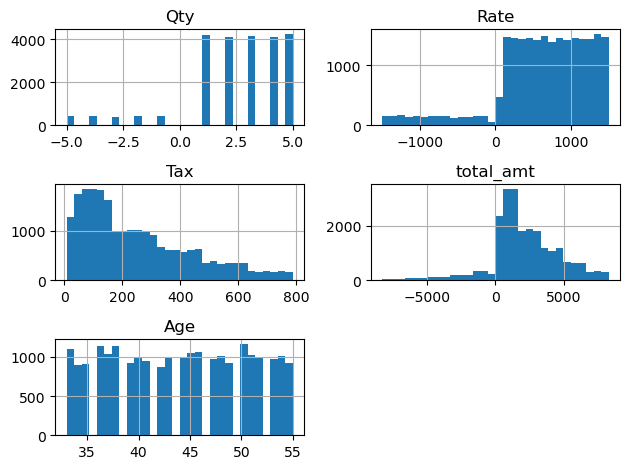

In [45]:
#Ans - #Continous variables are - Qty, Rate, Tax, total_amt and age. We will use these columns to make histograms as question has asked.
       #Categorical variables are Gender, Store Type, Product Category, Product Sub-Category and  City-Code.

# - Creating Histograms for continous variables.

Customer_Final[['Qty','Rate','Tax','total_amt','Age']].hist(bins=30)
plt.tight_layout()
plt.show()

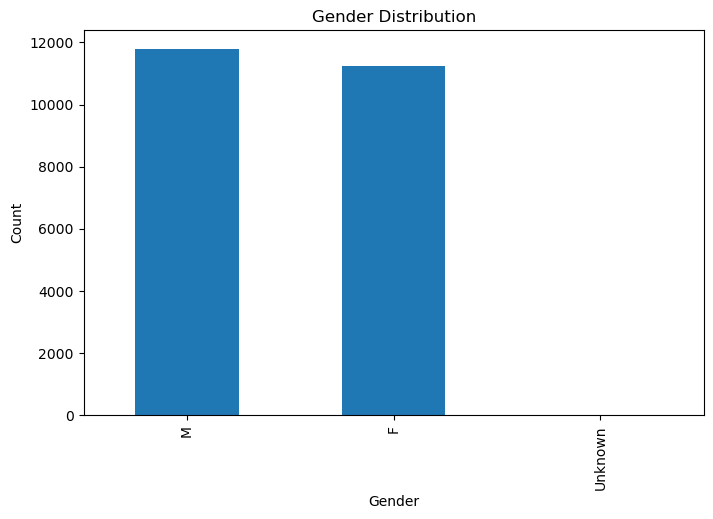

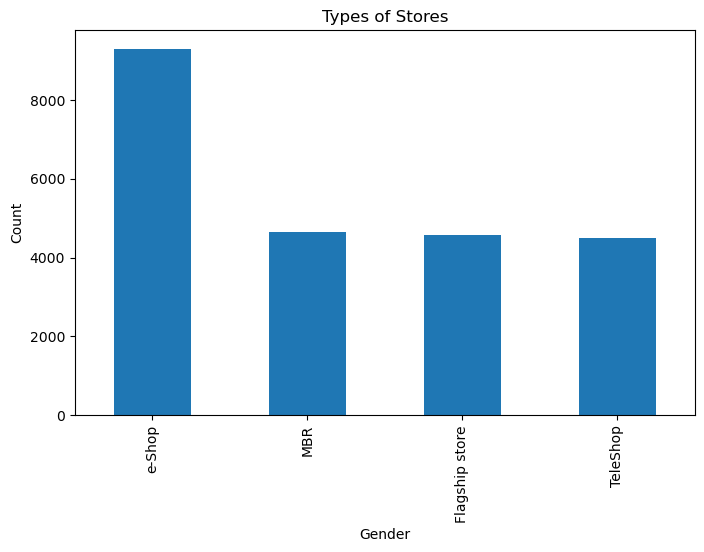

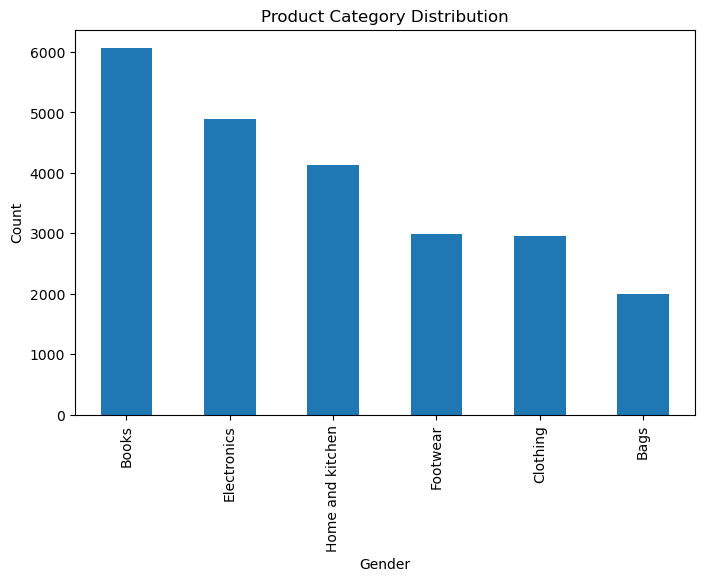

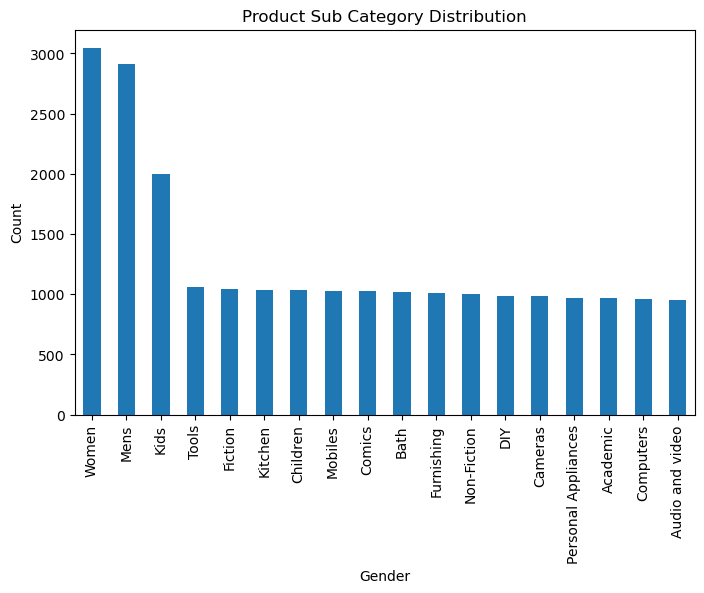

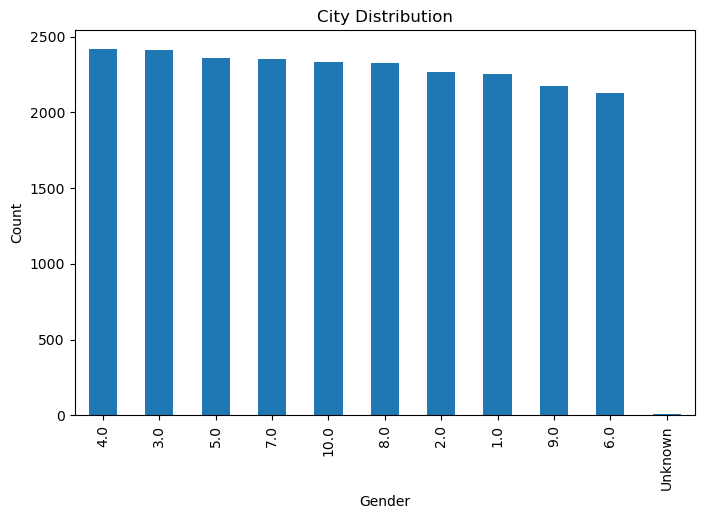

In [46]:

# - Creating frequency bars for categorical variables

Customer_Final['Gender'].value_counts().plot(kind='bar', figsize=(8,5))
plt.title("Gender Distribution")
plt.xlabel("Gender")
plt.ylabel("Count")
plt.show()

Customer_Final['Store_type'].value_counts().plot(kind='bar', figsize=(8,5))
plt.title("Types of Stores")
plt.xlabel("Gender")
plt.ylabel("Count")
plt.show()

Customer_Final['prod_cat'].value_counts().plot(kind='bar', figsize=(8,5))
plt.title("Product Category Distribution")
plt.xlabel("Gender")
plt.ylabel("Count")
plt.show()

Customer_Final['prod_subcat'].value_counts().plot(kind='bar', figsize=(8,5))
plt.title("Product Sub Category Distribution")
plt.xlabel("Gender")
plt.ylabel("Count")
plt.show()

Customer_Final['city_code'].value_counts().plot(kind='bar', figsize=(8,5))
plt.title("City Distribution")
plt.xlabel("Gender")
plt.ylabel("Count")
plt.show()

In [47]:
#Answer(4.a) - To get the time period of the available transaction data, we must know the minimum and maximum date.

min_date = Customer_Final['tran_date'].min()
max_date = Customer_Final['tran_date'].max()

Difference = max_date-min_date
days = Difference.days

years = days//365
months =(days%365) // 30

years, months

#As we can see in the result, the transaction data is covering approximately 3 years and 11 months.

(3, 11)

In [48]:
#Answer(4.b) - Count of transactions where the total amount of transaction was negative

(Customer_Final['total_amt'] < 0).sum()

np.int64(2164)

In [49]:
#Approach - Product category popularity is analyzed by grouping transactions based on gender and product category, and counting the number of 
#transactions for each group.

Customer_Final.groupby(['Gender','prod_cat'])['transaction_id'].count().sort_values(ascending=False).reset_index()

#Answer - Books Category is most popular in both the genders.

,Gender,prod_cat,transaction_id
0,M,Books,3116
1,F,Books,2946
2,M,Electronics,2567
3,F,Electronics,2328
4,M,Home and kitchen,2132
5,F,Home and kitchen,1993
6,F,Footwear,1528
7,M,Clothing,1518
8,M,Footwear,1467
9,F,Clothing,1439


In [50]:
#Maximum customers per city 

Customer_Final.groupby('city_code')['cust_id'].nunique().sort_values(ascending=False).reset_index()

,city_code,cust_id
0,3.0,576
1,5.0,570
2,4.0,569
3,7.0,563
4,8.0,551
5,10.0,546
6,2.0,546
7,1.0,535
8,9.0,532
9,6.0,516


In [51]:
#Maximum % of customers per city. 

city_counts = Customer_Final.groupby('city_code')['cust_id'].nunique()
percentage = (city_counts / city_counts.sum()) * 100
percentage.reset_index().sort_values(by='cust_id', ascending=False)

#Answer - "City code 3.0 has the maximum number of customers, contributing approximately 10.46% of the total customer base."

,city_code,cust_id
2,3.0,10.461315
4,5.0,10.352343
3,4.0,10.334181
6,7.0,10.225209
7,8.0,10.007265
9,10.0,9.916455
1,2.0,9.916455
0,1.0,9.716673
8,9.0,9.662187
5,6.0,9.371595


In [52]:
#(A) Maximum products sold by value

Customer_Final.groupby('Store_type')['total_amt'].sum().reset_index().sort_values(by='total_amt', ascending=False)

,Store_type,total_amt
3,e-Shop,1.984262e+07
0,Flagship store,9.721597e+06
1,MBR,9.674941e+06
2,TeleShop,9.372134e+06


In [53]:
#(B) Maximum products sold by quantity

Customer_Final.groupby('Store_type')['Qty'].sum().reset_index().sort_values(by='Qty', ascending=False)

,Store_type,Qty
3,e-Shop,22790
1,MBR,11195
0,Flagship store,11142
2,TeleShop,10993


In [54]:
#Answers - 
#e-Shop sells the maximum products both in terms of total value(1.984262e+07) and quantity(22790), 
#indicating it is the most dominant sales channel among all store types

In [55]:
#Approach - We would first create a filtered dataframe where we get the details for only Flagship stores and categories - Electronics & Clothing.

Flagship_data = Customer_Final[(Customer_Final['Store_type'] == 'Flagship store') & 
(Customer_Final['prod_cat'].isin(['Electronics', 'Clothing']))]

# Now we will check for total amount earned for this data.

Flagship_data.groupby('prod_cat')['total_amt'].sum().sort_values(ascending=False).reset_index()

#Answer - The total revenue from Electronics and Clothing categories in Flagship stores was calculated by 
         #filtering relevant transactions and aggregating total transaction amounts. The results show the contribution of each category separately

,prod_cat,total_amt
0,Electronics,2215136.04
1,Clothing,1194423.23


In [56]:
#Approach - Firstly we will create a filtered dataframe which only contains male gender and Electronics product category.

Male_df =  Customer_Final[(Customer_Final['Gender'] == 'M') & 
(Customer_Final['prod_cat'] == 'Electronics')]

Male_df.groupby('prod_cat')['total_amt'].sum().sort_values(ascending=False).reset_index()

#Answer - The total amount earned from males in Electronics Category is approx 5711351.62.

,prod_cat,total_amt
0,Electronics,5711351.62


In [57]:
#Approach - Firstly, we will create a filtered dataframe with no negative amount.

positive_df = Customer_Final[Customer_Final['total_amt'] > 0]

unique_cust = positive_df.groupby('cust_id')['transaction_id'].nunique()

final_count = (unique_cust > 10).sum()

final_count


#Answer - After removing all transactions with negative amounts, I grouped the data by customer ID and counted unique transactions per customer. 
#I then filtered customers with more than 10 transactions and found that 6 customers meet this criteria.

np.int64(6)

In [58]:
#Step 1 - first we have to filter customers ages between 25 and 35

age_df = Customer_Final[
    (Customer_Final['Age'] >= 25) &
    (Customer_Final['Age'] <= 35)
]

#(a) total amount spent for “Electronics” and “Books” product categories

age_df[age_df['prod_cat'].isin(['Electronics','Books'])]['total_amt'].sum()

# I filtered transactions belonging to Electronics and Books categories and calculated total spend


np.float64(2794995.84)

In [59]:
#(b) total amount spent by these customers between 1st Jan, 2014 to 1st Mar, 2014

age_df[
    (age_df['tran_date'] >= '2014-01-01') &
    (age_df['tran_date'] <= '2014-03-01')
]['total_amt'].sum()

#(b) I filtered transactions within the specified date range and calculated the total amount.

np.float64(206052.66499999998)